# Intel GPU加速UVR5人声伴奏分离


## 安装依赖
升级pip


安装torch+xpu及intel-extension-for-pytorch

安装openai-whisper

In [8]:
%pip  install --upgrade pip
%pip  install torch==2.7.0 torchvision==0.22.0 torchaudio==2.7.0 --index-url https://download.pytorch.org/whl/xpu
%pip  install intel-extension-for-pytorch==2.7.10+xpu --index-url https://pytorch-extension.intel.com/release-whl/stable/xpu/cn/
%pip  install openai-whisper
%pip  install librosa
%pip  install soundfile
%pip  install resampy

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/xpu
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pytorch-extension.intel.com/release-whl/stable/xpu/cn/
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://mirrors.tuna.tsinghua.edu.cn/pyp

In [5]:
#下载示例工程里面已包含有修改源码后支持Intel GPU加速的库文件
!git clone https://www.modelscope.cn/studios/lpcarl/VoiceToSRT.git
%cd VoiceToSRT

D:\project\VoiceToSRT\VoiceToSRT


fatal: destination path 'VoiceToSRT' already exists and is not an empty directory.


## 示例代码
模型自动下载
调用本地Intel GPU资源，生成结果带有单词级时间戳
根据时间戳生成SRT格式

In [19]:
from vr import AudioPre
import os,torch

audio_path='./example/1.mp3'
agg = 10
sep_dir = os.path.dirname(audio_path)
device = torch.device("cuda" if torch.cuda.is_available() else "xpu" if torch.xpu.is_available() else "cpu")
extract_model = AudioPre(
    agg=agg,
    model_path="./HP5_only_main_vocal.pth",  # 模型权重文件路径
    device=device,
    is_half=False,
)
extract_model._path_audio_(
    music_file=audio_path,  # 必须是音频文件路径，不要传目录
    ins_root=sep_dir,
    vocal_root=sep_dir,
    format="mp3",
)
name = os.path.basename(audio_path)
instrumental_audio_path = os.path.join(sep_dir, f"instrument_{name}_10.mp3")
vocal_audio_path = os.path.join(sep_dir, f"vocal_{name}_10.mp3")

100%|██████████████████████████████████████████████████████████████████████████████████| 18/18 [00:08<00:00,  2.24it/s]


In [16]:
from IPython.display import Audio

# 播放背景音乐
Audio(instrumental_audio_path)



In [17]:
#播放人声
Audio(vocal_audio_path)

## 运行过程中资源使用情况截图
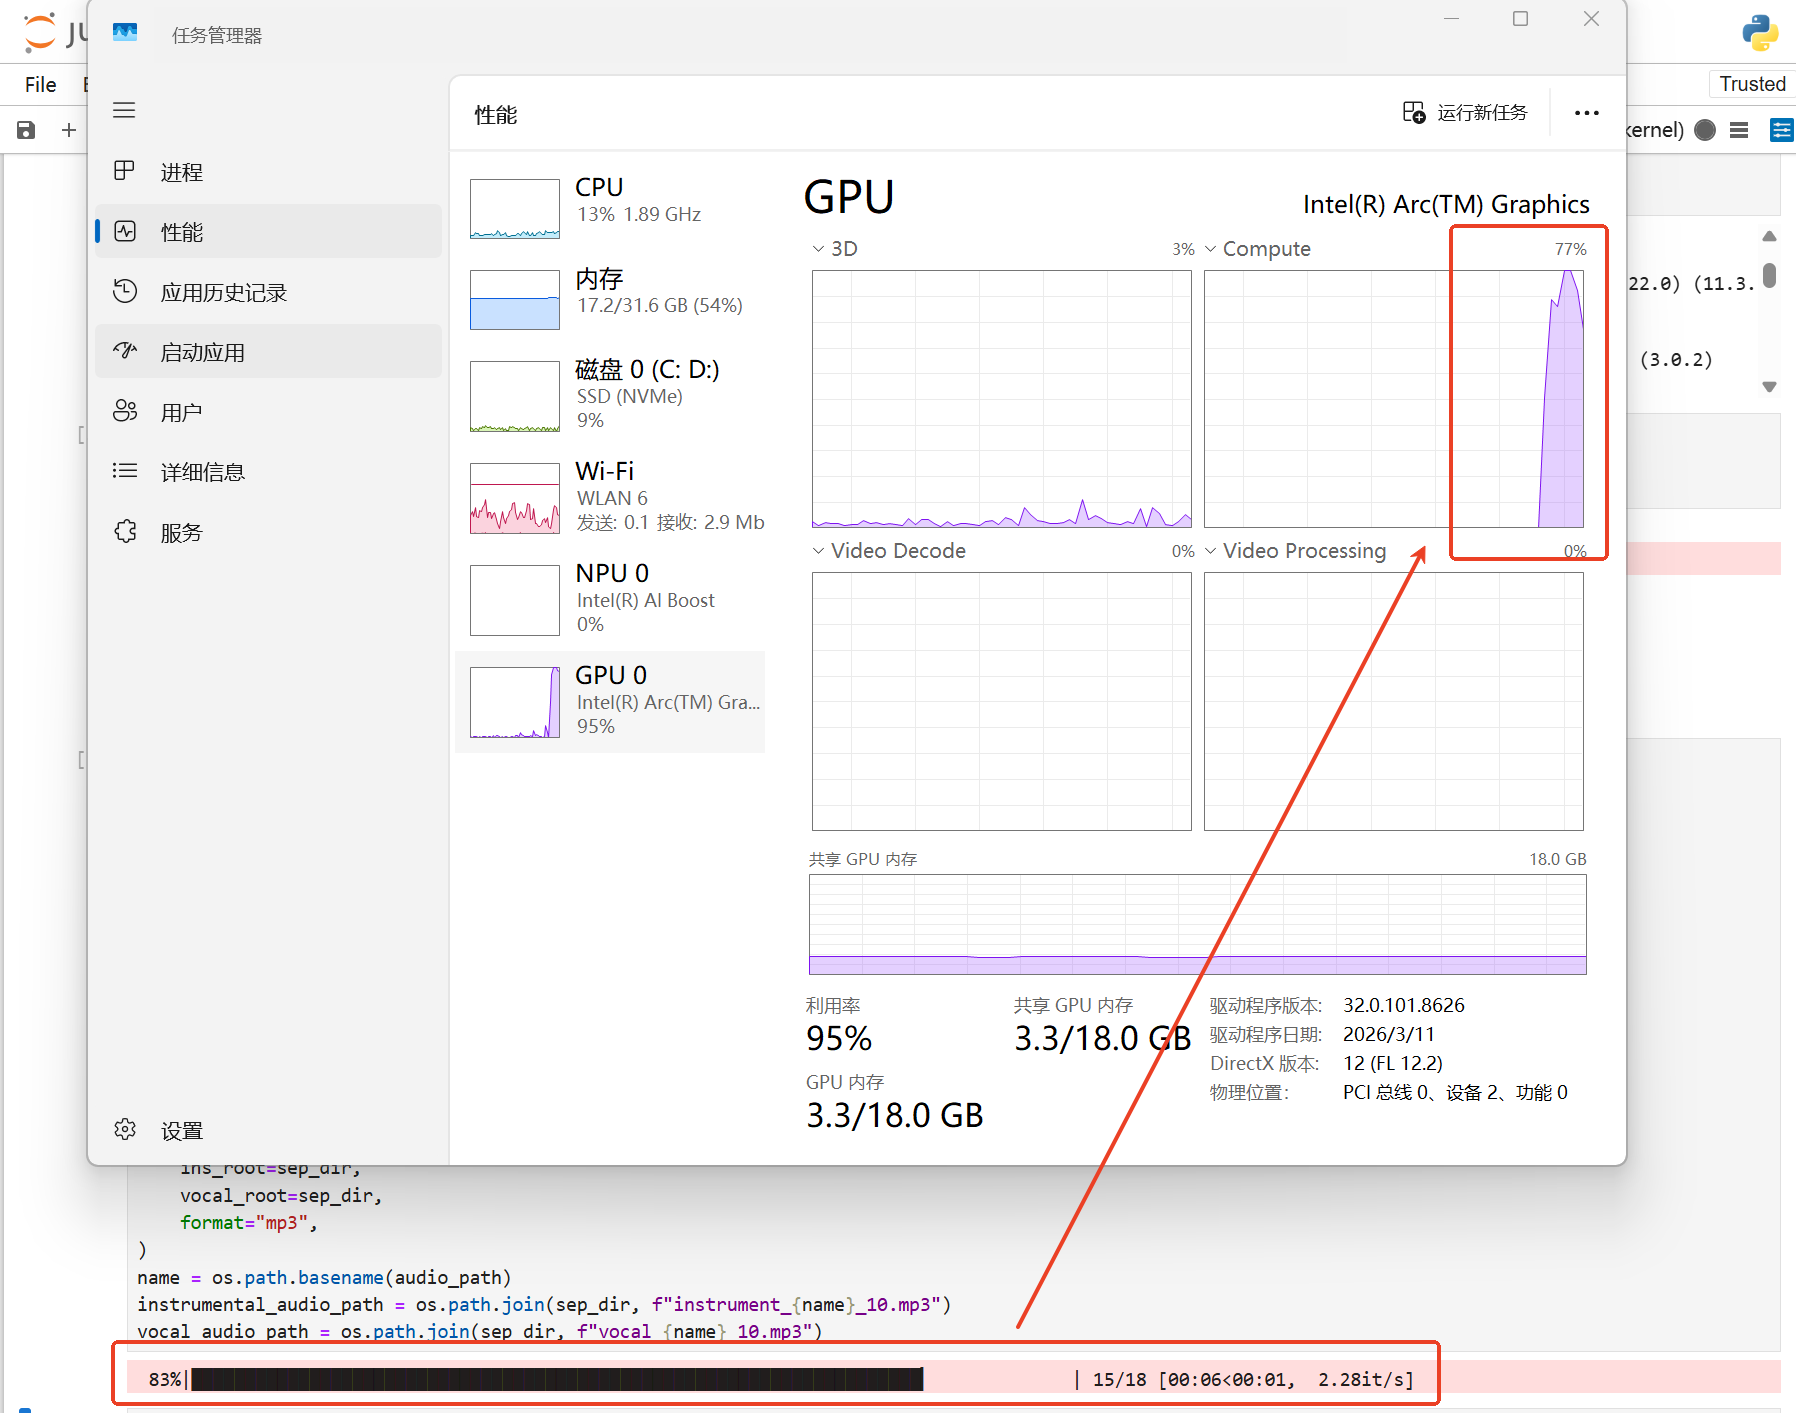